# **Objective**
The objective of this project is to develop a denoising autoencoder that can reconstruct clean handwritten digit images from noisy inputs using the MNIST dataset. The project demonstrates how deep learning can be used for image denoising while preserving the original structure of the images.

# **1. Import Libraries**
libraries required for data processing, model building, and visualization.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

# **2. Load and Preprocess MNIST**
MNIST handwritten digit dataset for training and testing.

In [20]:
(x_train,_),(x_test,_)=mnist.load_data()
print("Training Images:",x_train.shape)
print("Testing Images:",x_test.shape)

Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


In [21]:
x_train=x_train.astype('float32')/255.
x_test=x_test.astype('float32')/255.
x_train=np.reshape(x_train,(len(x_train),28,28,1))
x_test=np.reshape(x_test,(len(x_test),28,28,1))

# **3. Add Artificial Noise**
Added Gaussian noise to the original images to create the model's input data.

In [22]:
noise_factor = 0.4
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)


# **4. Visualize Original vs Noisy Images**
Displaying sample original and noisy images for comparison.

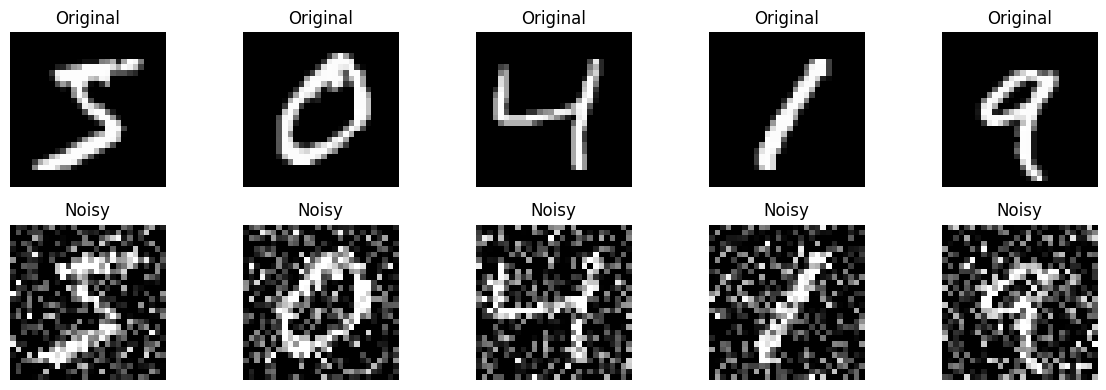

In [23]:
plt.figure(figsize=(12,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.title("Original")
    plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.title("Noisy")
plt.tight_layout()
plt.show()

# **5. Build Denoising Autoencoder**
Designing the encoder-decoder architecture using convolutional layers.

In [24]:
input_img = Input(shape=(28,28,1))
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(1, (3,3),
                 activation='sigmoid',
                 padding='same')(x)
autoencoder = Model(input_img, decoded)
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

# **6. Train the Model**
Training the autoencoder using noisy images as input and clean images as the target.

In [25]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 165s 348ms/step - loss: 0.1528 - val_loss: 0.0999
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 163s 347ms/step - loss: 0.0976 - val_loss: 0.0940
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 348ms/step - loss: 0.0936 - val_loss: 0.0914
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 335ms/step - loss: 0.0914 - val_loss: 0.0906
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 334ms/step - loss: 0.0899 - val_loss: 0.0885
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 335ms/step - loss: 0.0888 - val_loss: 0.0877
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 158s 337ms/step - loss: 0.0880 - val_loss: 0.0871
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 157s 334ms/step - loss: 0.0873 - val_loss: 0.0864
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 160s 342ms/step - loss: 0.0867 - val_loss: 0.0858
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 156s 333ms/step - loss: 0.0863 - val_loss: 0.0855
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 207s 343ms/step - loss: 0.0859 - val_loss: 0.0852
Epoch 12

# **7. Plot Training Loss**
Visualizing the training and validation loss to monitor model performance.

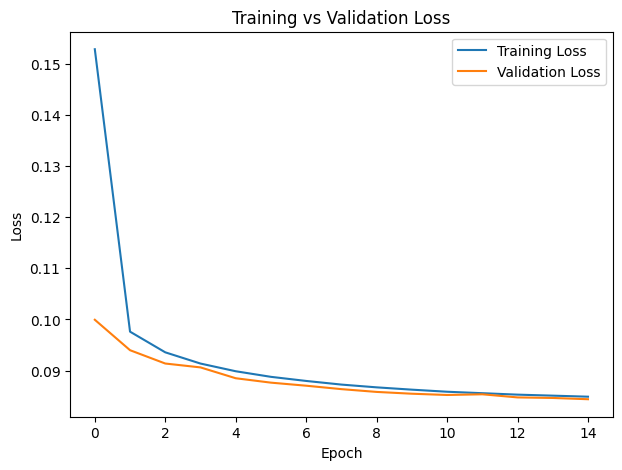

In [26]:
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


# **8. Generate Denoised Images**
Using the trained model to reconstruct clean images from noisy inputs.

In [27]:
decoded_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step


# **9. Comparing Results**
Comparing the original, noisy, and reconstructed images side by side.

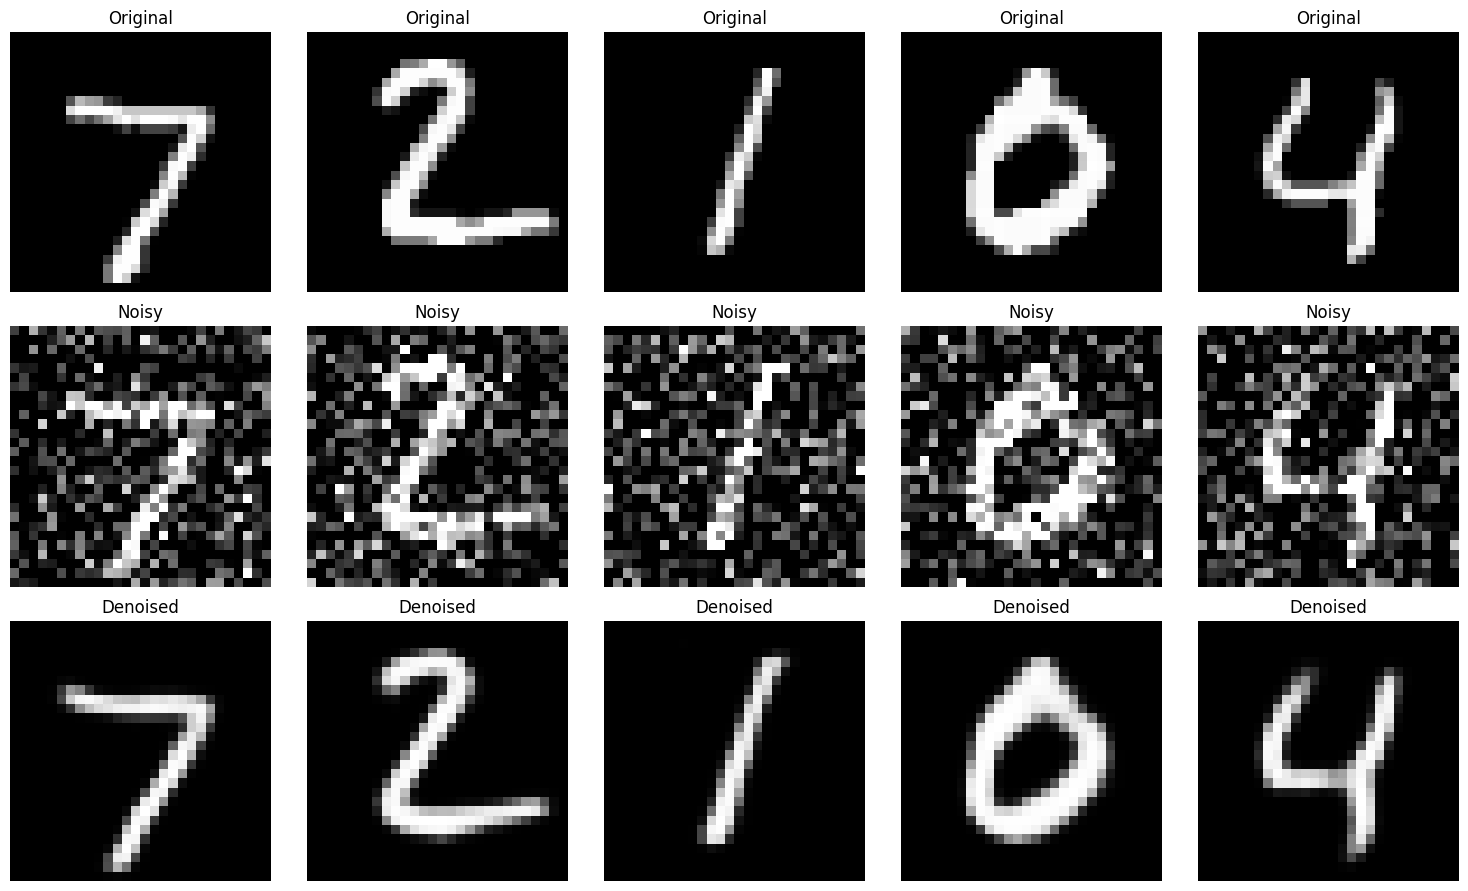

In [28]:
n = 5
plt.figure(figsize=(15,9))
for i in range(n):
    plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")
    plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")
    plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_images[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")
plt.tight_layout()
plt.show()

**10. some extra things for learning purpose**

In [29]:
mse = np.mean((x_test - decoded_images) ** 2)
print("Mean Squared Error:", round(mse, 5))

Mean Squared Error: 0.0074


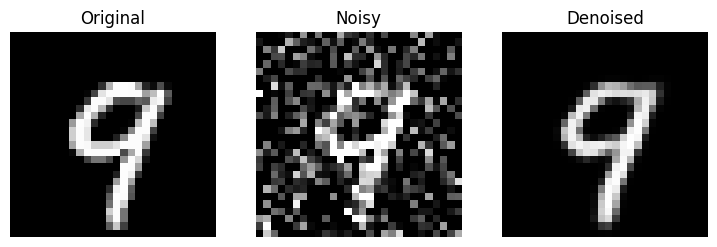

In [30]:
index = 12
plt.figure(figsize=(9,3))
plt.subplot(1,3,1)
plt.imshow(x_test[index].reshape(28,28), cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(x_test_noisy[index].reshape(28,28), cmap="gray")
plt.title("Noisy")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(decoded_images[index].reshape(28,28), cmap="gray")
plt.title("Denoised")
plt.axis("off")
plt.show()

# **Observation**
After training the model, I noticed that it was able to reduce most of the noise present in the images. The reconstructed images looked much clearer than the noisy ones, and in most cases the handwritten digits could still be recognized easily. As the number of training epochs increased, both the training and validation loss became lower, which indicated that the model was improving its performance. A few reconstructed images were slightly blurred, especially when the added noise was high, but the overall shape of the digits was still maintained.

# **Conclusion**
This project gave me a practical understanding of how a denoising autoencoder works. By training the model with noisy images as input and clean images as output, it learned to recover the important features of the handwritten digits while removing unwanted noise. Although the reconstructed images were not exactly the same as the originals, the results were good enough to show that the model was effective for this task. Overall, the experiment successfully demonstrated the use of autoencoders for image denoising.